# Descrição do Projeto

A empresa Taxi Corrida Maluca coletou dados históricos sobre pedidos de táxi nos aeroportos. Para atrair mais motoristas durante o horário de pico, precisamos prever a quantidade de pedidos de táxi para a próxima hora. 	
Construa um modelo para tal predição.

A métrica REQM no conjunto de teste não deve ser superior a 48.

Instruções do projeto

1. Faça download dos dados e faça uma nova amostragem em uma hora.
2. Analise os dados
3. Treine diferentes modelos com diferentes hiperparâmetros. A amostra de teste deve ser 10% do conjunto de dados inicial.
4. Teste os dados usando a amostra de teste e forneça uma conclusão.

Descrição dos dados

Os dados são armazenados no arquivo `taxi.csv`. O número de pedidos está na coluna `num_orders`.

# Imports e Configs Iniciais

In [1]:
# importando as bilbliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Configurações 
from sklearn.metrics import mean_squared_error
import time
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import RandomizedSearchCV

#importando Modelos de ML
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score


warnings.filterwarnings('ignore') # para ignorar os warnings do sklearn
os.environ["PYTHONWARNINGS"] = "ignore" # para ignorar os warnings do sklearn (em alguns casos, o filtro acima não funciona, então usamos essa variável de ambiente)
from IPython.display import display # para mostrar o dataset de forma mais legível

In [2]:
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

#  📖 Dicionário de Dados: Rusty Bargain,

    
   | Coluna (no arquivo) | Nome sugerido (snake_case) | O que representa |
|---|---|---|
| datetime | date_time| Data em que o taxi foi chamado. |
| num_orders| num_orders |  **Alvo**: quantidade de pedidos realizados |



# Carregamento dos Dados

In [3]:
# importando o dataset
df = pd.read_csv('taxi.csv', index_col=0, parse_dates=['datetime'])

# visualizando as primeiras linhas do dataset
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


# Pré-Processamento

In [4]:
# renomear coluna
df.rename(columns={'datetime': 'date_time'}, inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [6]:
df.sort_index(inplace=True)
df = df.resample('H').sum()
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


In [7]:
# Verificando a data inicial e final
data_inicio = df.index.min()
data_fim = df.index.max()

print(f"Início do período: {data_inicio}")
print(f"Fim do período: {data_fim}")
print(f"Duração total: {data_fim - data_inicio}")

Início do período: 2018-03-01 00:00:00
Fim do período: 2018-08-31 23:00:00
Duração total: 183 days 23:00:00


In [8]:
# Criando um intervalo esperado completo
intervalo_esperado = pd.date_range(start=data_inicio, end=data_fim, freq='1H')

if len(df) == len(intervalo_esperado):
    print("✅ A série está completa, sem horas faltando!")
else:
    print(f"⚠️ Atenção: Faltam {len(intervalo_esperado) - len(df)} horas nos seus dados.")

✅ A série está completa, sem horas faltando!


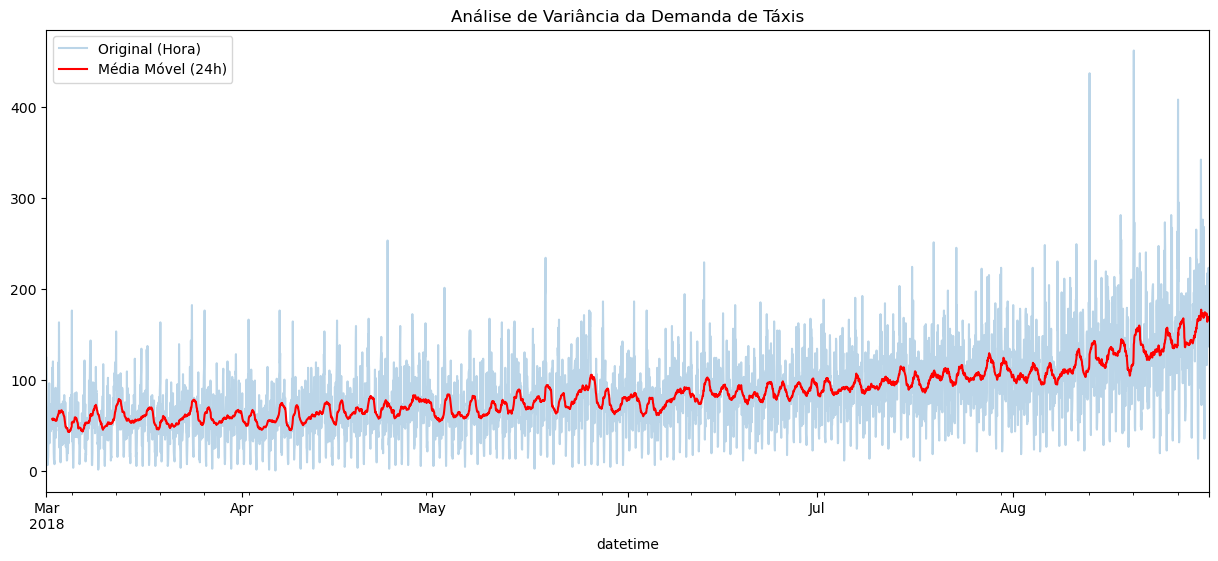

In [9]:
# Plotando os dados originais com uma média móvel para ver a tendência
plt.figure(figsize=(15, 6))
df['num_orders'].plot(alpha=0.3, label='Original (Hora)')
df['num_orders'].rolling(window=24).mean().plot(label='Média Móvel (24h)', color='red')
plt.title('Análise de Variância da Demanda de Táxis')
plt.legend()
plt.show()

- A linha vermelha mostra uma tendência de crescimento clara, especialmente a partir de julho. Isso significa que a média de pedidos está aumentando

- A série não é estacionária

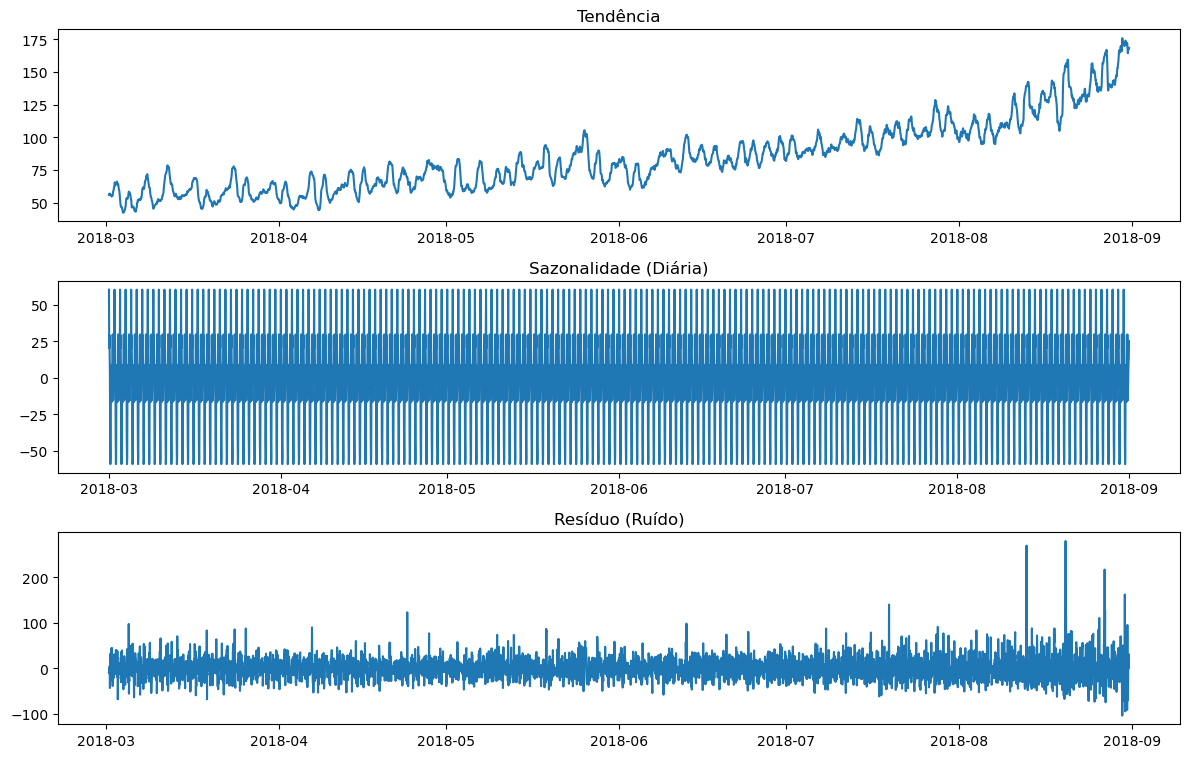

In [10]:
# Fazer a decomposição (período de 24 horas para capturar o ciclo do dia)
decomposicao = seasonal_decompose(df['num_orders'], model='additive', period=24)

# Plotar os resultados
plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 2)
plt.plot(decomposicao.trend)
plt.title('Tendência')

plt.subplot(4, 1, 3)
plt.plot(decomposicao.seasonal)
plt.title('Sazonalidade (Diária)')

plt.subplot(4, 1, 4)
plt.plot(decomposicao.resid)
plt.title('Resíduo (Ruído)')

plt.tight_layout()
plt.show()

<Axes: xlabel='datetime'>

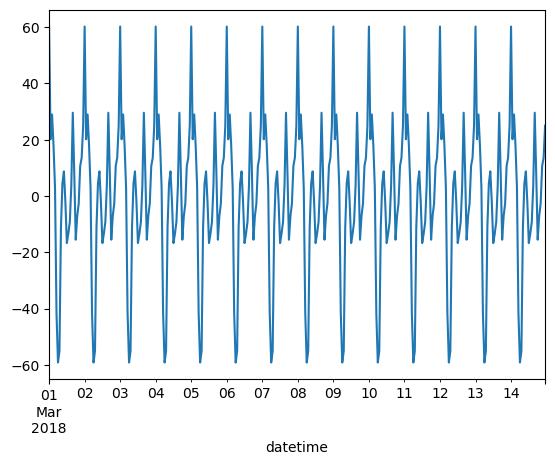

In [11]:
decomposed = decomposicao
decomposed.seasonal.head(336).plot() #decompondo em duas semanas para visualizar melhor a sazonalidade diária

🧠 O mapa mental das features de séries temporais

Quando queremos prever um valor no tempo t, pensamos em três perguntas:

               PREVER y(t)
                   │
        ┌──────────┼──────────┐
        │          │          │
     PASSADO    CALENDÁRIO   TENDÊNCIA
      (lags)      (date)      (rolling)

In [12]:
def make_features(df, max_lag=24):
    df_f = df.copy()
    
    # 1. CALENDÁRIO (CÍCLICO) - Perfeito!
    df_f['hour'] = df_f.index.hour
    df_f['day_of_week'] = df_f.index.dayofweek
    df_f['month'] = df_f.index.month

    df_f['hour_sin'] = np.sin(2 * np.pi * df_f['hour'] / 24)
    df_f['hour_cos'] = np.cos(2 * np.pi * df_f['hour'] / 24)
    df_f['dow_sin'] = np.sin(2 * np.pi * df_f['day_of_week'] / 7)
    df_f['dow_cos'] = np.cos(2 * np.pi * df_f['day_of_week'] / 7)
    df_f['month_sin'] = np.sin(2 * np.pi * df_f['month'] / 12)
    df_f['month_cos'] = np.cos(2 * np.pi * df_f['month'] / 12)

    df_f = df_f.drop(columns=['hour', 'day_of_week', 'month'])


    # 3. LAGS (Atrasos)
    # Importante: O lag deve começar em 1 para não incluir o valor atual
    for lag in range(1, max_lag + 1):
        df_f[f'lag_{lag}'] = df_f['num_orders'].shift(lag)

    # 4. Lag semanal (168 horas)
    df_f['lag_168'] = df_f['num_orders'].shift(168) 

    # 4. MÉDIAS MÓVEIS (Curto e Longo Prazo)
    df_f['rolling_mean_24'] = df_f['num_orders'].shift(1).rolling(24).mean()
    df_f['rolling_mean_7d'] = df_f['num_orders'].shift(1).rolling(168).mean() # 7 dias * 24 horas = 168 horas

    # 5. VOLATILIDADE (Desvio Padrão Móvel)
    df_f['rolling_std_6'] = df_f['num_orders'].shift(1).rolling(6).std()
    df_f['rolling_std_12'] = df_f['num_orders'].shift(1).rolling(12).std()

    # 6. DIFERENÇAS (CORRIGIDO: adicionado shift para evitar leak)
    df_f['diff_1'] = df_f['num_orders'].shift(1) - df_f['num_orders'].shift(2) # diferença de 1 hora
    df_f['diff_24'] = df_f['num_orders'].shift(1) - df_f['num_orders'].shift(25) # diferença de 24 horas (comparando com o mesmo horário do dia anterior)



    return df_f.dropna()

# criando as features
df_final = make_features(df, max_lag=24)

In [13]:
df_final.head()

,num_orders,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,lag_168,rolling_mean_24,rolling_mean_7d,rolling_std_6,rolling_std_12,diff_1,diff_24
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-03-08 00:00:00,143,0.000000,1.000000,0.433884,-0.900969,1.0,6.123234e-17,94.0,127.0,108.0,76.0,50.0,99.0,48.0,46.0,51.0,43.0,55.0,34.0,58.0,34.0,50.0,38.0,17.0,19.0,10.0,73.0,66.0,24.0,121.0,100.0,124.0,60.041667,54.226190,26.658332,30.466450,-33.0,47.0
2018-03-08 01:00:00,78,0.258819,0.965926,0.433884,-0.900969,1.0,6.123234e-17,143.0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,46.0,51.0,43.0,55.0,34.0,58.0,34.0,50.0,38.0,17.0,19.0,10.0,73.0,66.0,24.0,121.0,85.0,61.833333,54.339286,33.921478,34.924160,49.0,43.0
2018-03-08 02:00:00,65,0.500000,0.866025,0.433884,-0.900969,1.0,6.123234e-17,78.0,143.0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,46.0,51.0,43.0,55.0,34.0,58.0,34.0,50.0,38.0,17.0,19.0,10.0,73.0,66.0,24.0,71.0,60.041667,54.297619,26.927062,34.149737,-65.0,-43.0
2018-03-08 03:00:00,68,0.707107,0.707107,0.433884,-0.900969,1.0,6.123234e-17,65.0,78.0,143.0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,46.0,51.0,43.0,55.0,34.0,58.0,34.0,50.0,38.0,17.0,19.0,10.0,73.0,66.0,66.0,61.750000,54.261905,29.494067,32.519807,-13.0,41.0
2018-03-08 04:00:00,60,0.866025,0.500000,0.433884,-0.900969,1.0,6.123234e-17,68.0,65.0,78.0,143.0,94.0,127.0,108.0,76.0,50.0,99.0,48.0,46.0,51.0,43.0,55.0,34.0,58.0,34.0,50.0,38.0,17.0,19.0,10.0,73.0,43.0,61.833333,54.273810,32.381579,31.393398,3.0,2.0


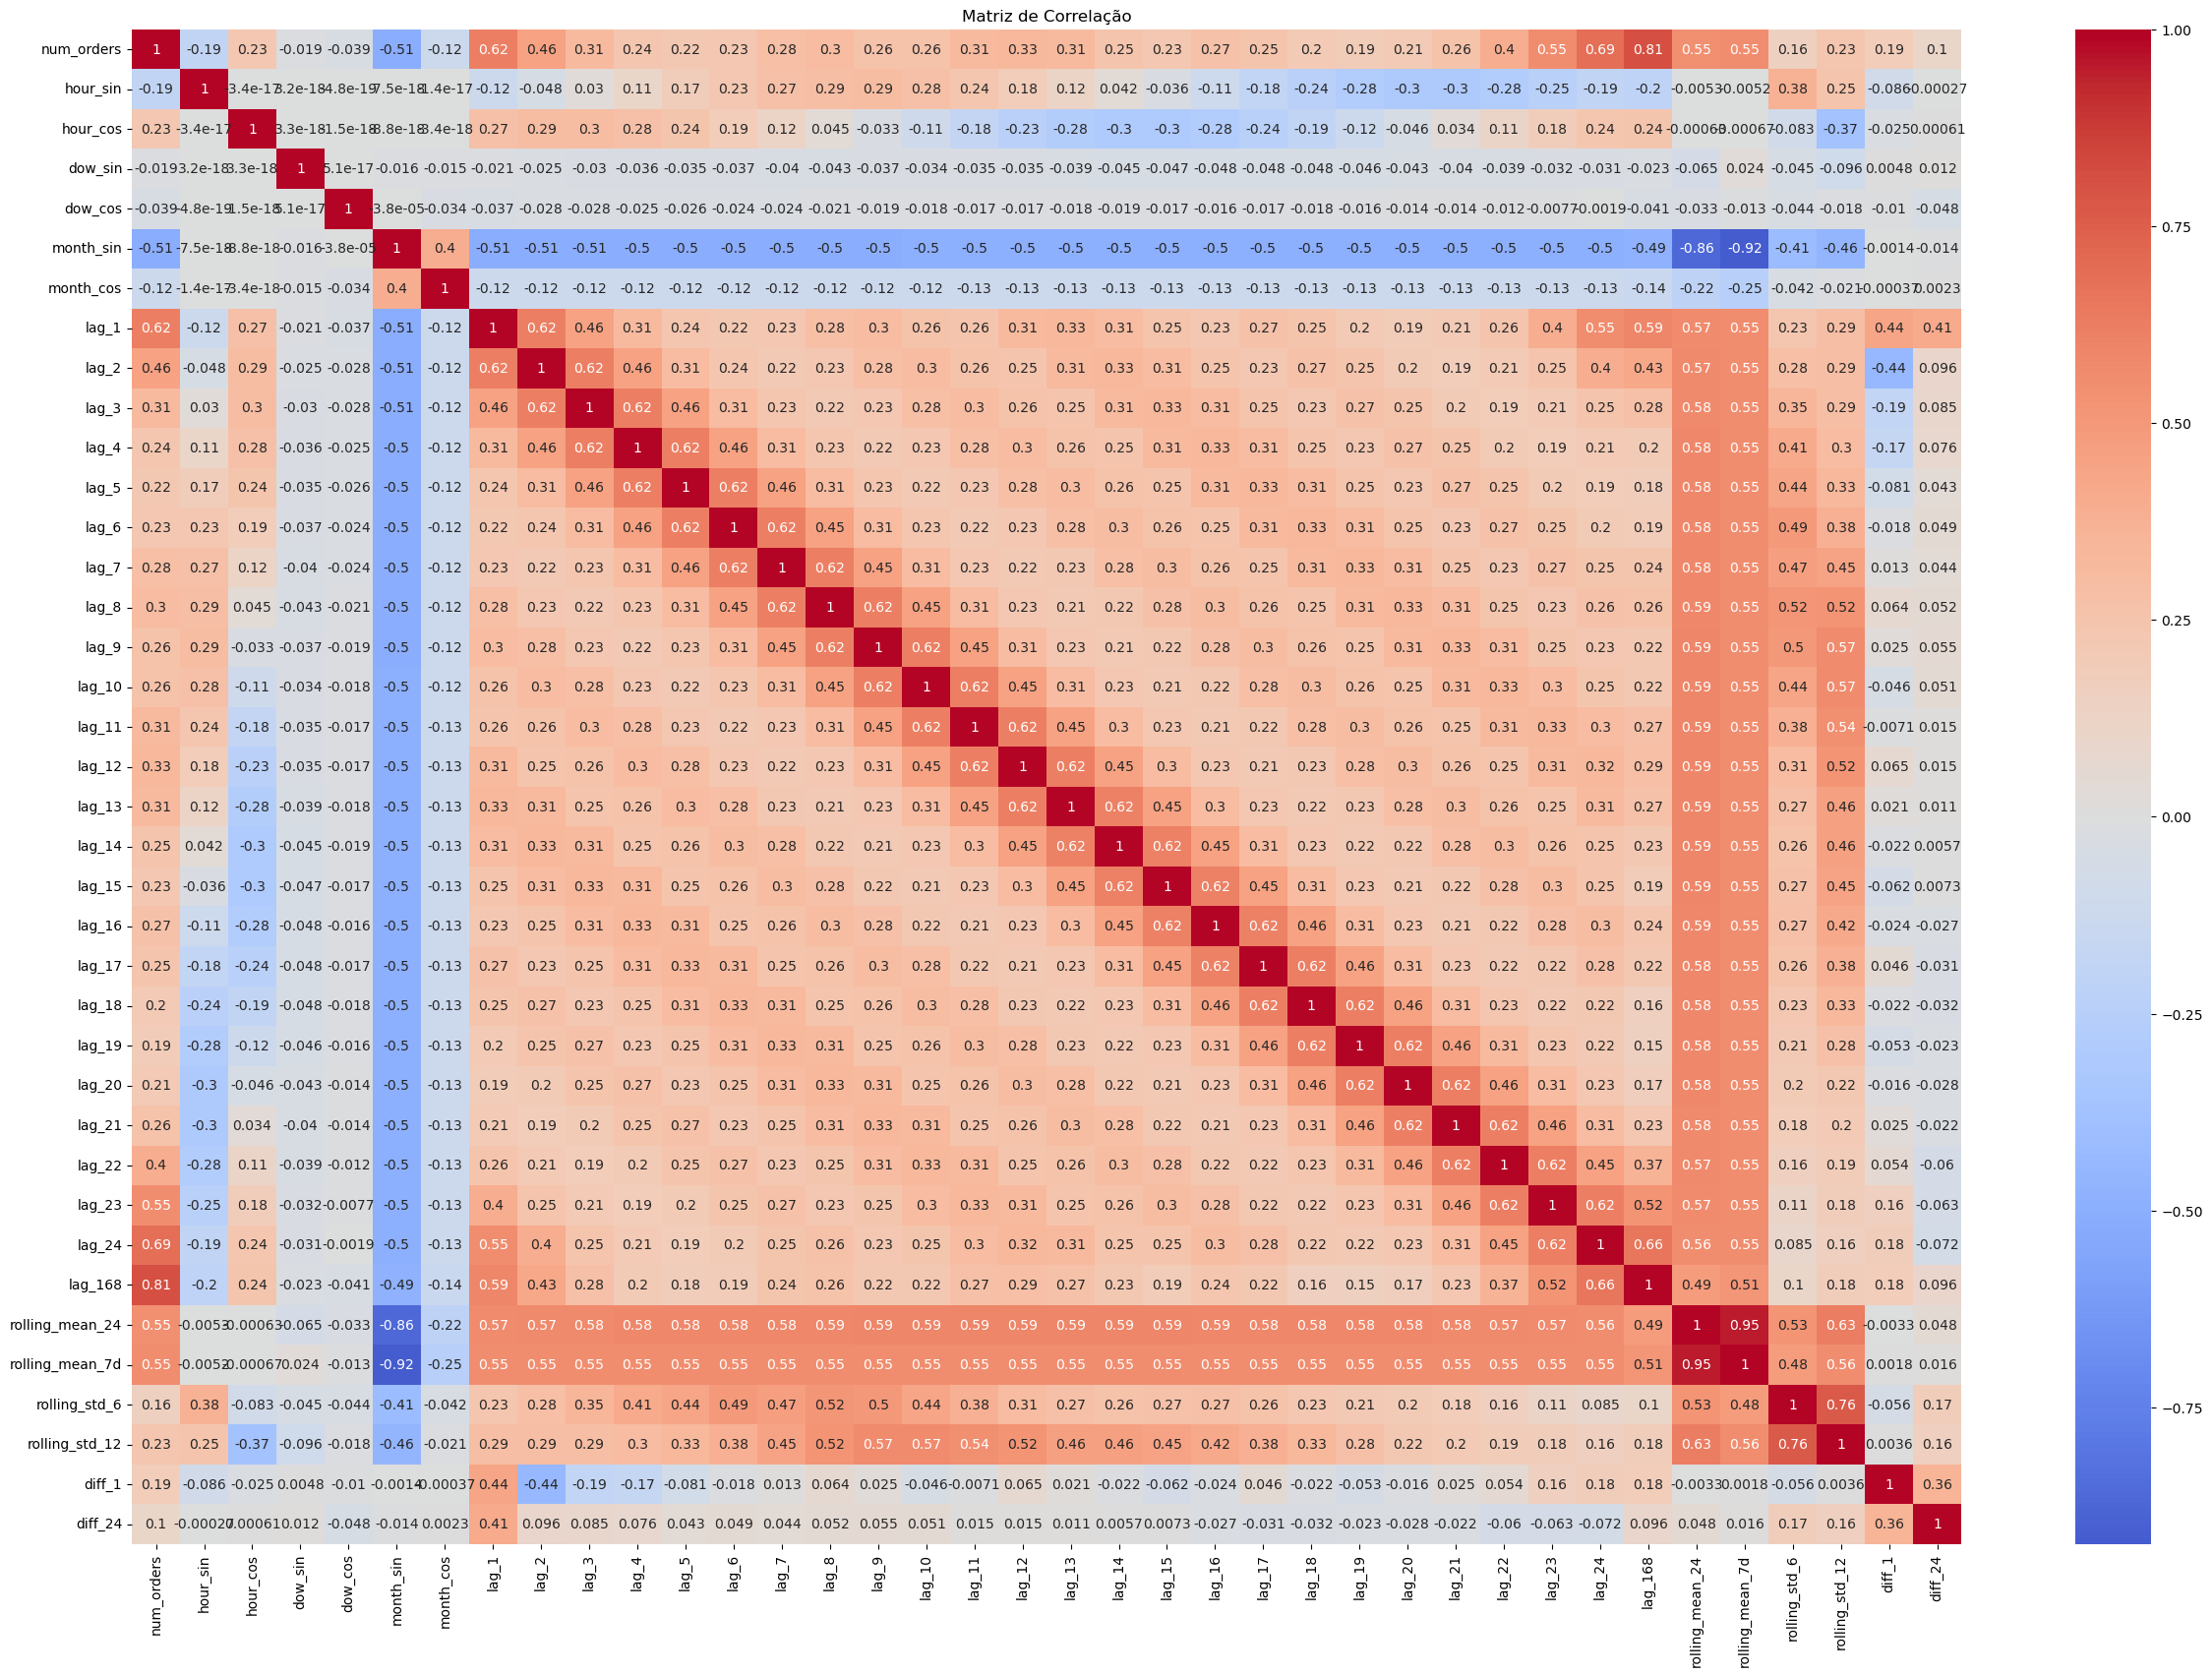

In [14]:
# testar multicolinearidade entre as features e a variável alvo - heatmap de correlação

plt.figure(figsize=(30, 20))
sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.show()

In [15]:
# Dropar as features altamente correlacionadas (correlação > 0.9 ou < -0.9)
#df_final = df_final.drop(columns=['lag_3','lag_4','lag_5','lag_6','lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'rolling_mean_7d', 'rolling_std_12', 'diff_1', 'diff_24'])

In [16]:
# Divisão dos dados (10% final para teste)
train, test = train_test_split(df_final, shuffle=False, test_size=0.1)

print(f"Treino: {train.index.min()} até {train.index.max()}")
print(f"Teste: {test.index.min()} até {test.index.max()}")

Treino: 2018-03-08 00:00:00 até 2018-08-14 06:00:00
Teste: 2018-08-14 07:00:00 até 2018-08-31 23:00:00


In [17]:
X_train = train.drop(['num_orders'], axis=1)
y_train = train['num_orders']

X_test = test.drop(['num_orders'], axis=1)
y_test = test['num_orders']

## Treinamento 

In [18]:
pipeline_dummy = Pipeline([
    ('model', DummyRegressor(strategy='mean')) # Prevê sempre a média do treino
])

In [19]:
#-----------------------------------Comparação de Modelos ---------------------------------

# 1. Configuração da Validação Cruzada Temporal
# n_splits=5 
tscv = TimeSeriesSplit(n_splits=5)

# 2. Definição dos modelos
models = {
    "Linear Regression": Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state= RANDOM_STATE),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE, verbose=0),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=RANDOM_STATE, verbose=-1),
    "CatBoost": CatBoostRegressor(n_estimators=100, random_state=RANDOM_STATE, verbose=0)
}

cv_results = []

# 3. Loop de Comparação (Validação Cruzada no conjunto de TREINO)
for name, model in models.items():
    start_time = time.time()
    
    scores = cross_val_score(model, X_train, y_train, cv=tscv, 
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    
    rmse_cv = -scores.mean() 
    duration = time.time() - start_time

    cv_results.append({
        "Model": name,
        "RMSE_CV": round(rmse_cv, 2),
        "CV_Std": round(scores.std(), 2), # Importante para ver a estabilidade
        "Time (s)": round(duration, 4)
    })
    
    # 4. Exibição em uma tabela
df_results = pd.DataFrame(cv_results).sort_values(by="RMSE_CV")
display(df_results)

,Model,RMSE_CV,CV_Std,Time (s)
1,Random Forest,23.18,3.75,5.9385
0,Linear Regression,23.27,3.18,1.4799
3,LightGBM,23.62,3.61,2.3679
2,XGBoost,24.24,3.74,1.1976
4,CatBoost,24.27,3.92,1.6761


# Tuning de hiperparâmetros

In [20]:
# FUNÇÃO DE TUNING
def tunar_modelo(nome, estimator, param_dist, X_train, y_train, tscv, n_iter=20):
    
    start = time.time()
    
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    search.fit(X_train, y_train)
    
    tempo = time.time() - start
    rmse = -search.best_score_ # O melhor score é negativo, então invertemos o sinal para obter o RMSE positivo
    
    return {
        'nome': nome,
        'modelo': search.best_estimator_,
        'rmse': rmse,
        'tempo': tempo,
        'params': search.best_params_
    }


# ESPAÇO DE BUSCA
param_xgb = {
    'n_estimators': [200, 500, 800, 1200],
    'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.6, 0.7, 0.85, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.85, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}



# LISTA DE MODELOS 
modelos = [
    ("XGBoost", XGBRegressor(random_state=RANDOM_STATE), param_xgb)
]


# TUNING 
resultados = []

for nome, modelo, params in modelos:
    resultado = tunar_modelo(nome, modelo, params, X_train, y_train, tscv)
    resultados.append(resultado)

# Analise do resultado do modelo escolhido

In [21]:
# comparação
df_resultados = pd.DataFrame([
    {
        'Modelo': r['nome'],
        'RMSE': r['rmse'],
        'Tempo (s)': r['tempo']
    }
    for r in resultados
]).sort_values(by='RMSE')

print("\n📊 Comparação dos Modelos:")
print(df_resultados)


📊 Comparação dos Modelos:
    Modelo       RMSE  Tempo (s)
0  XGBoost  23.047013  59.707135


In [22]:
modelo_escolhido = "XGBoost"

melhor = [r for r in resultados if r['nome'] == modelo_escolhido][0]

print(f"\n🏆 Modelo escolhido: {melhor['nome']}")
print("Melhores parâmetros:", melhor['params'])


# TREINO FINAL
modelo_final = melhor['modelo']
modelo_final.fit(X_train, y_train)

# PREDIÇÃO
y_pred = modelo_final.predict(X_test)

# MÉTRICA FINAL
rmse_test = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"\n📉 RMSE no teste: {rmse_test:.4f}")




🏆 Modelo escolhido: XGBoost
Melhores parâmetros: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}

📉 RMSE no teste: 39.5554


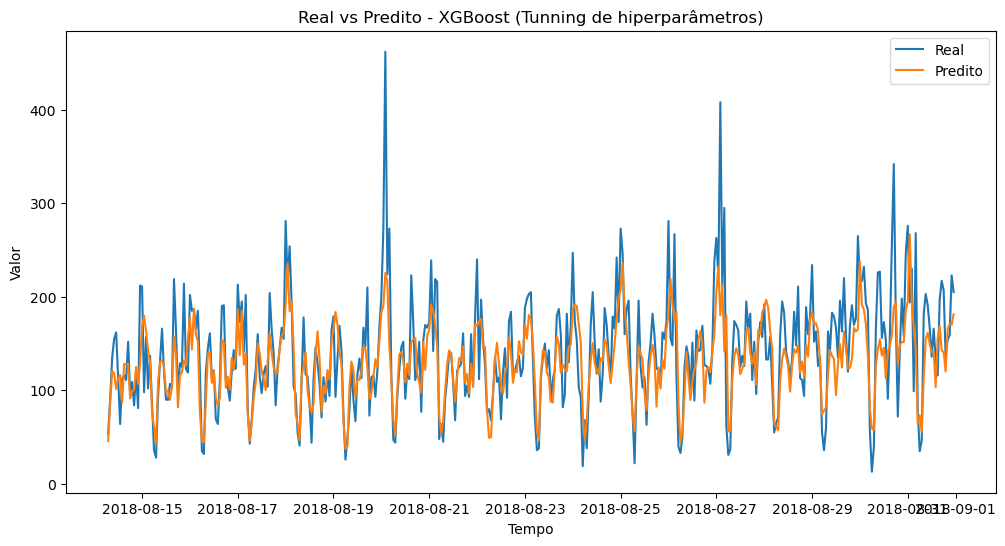

In [23]:
# PLOT

plt.figure(figsize=(12, 6))

if hasattr(y_test, "index"):
    plt.plot(y_test.index, y_test, label='Real')
    plt.plot(y_test.index, y_pred, label='Predito')
else:
    plt.plot(y_test, label='Real')
    plt.plot(y_pred, label='Predito')

plt.title("Real vs Predito - XGBoost (Tunning de hiperparâmetros)")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.legend()

plt.show()

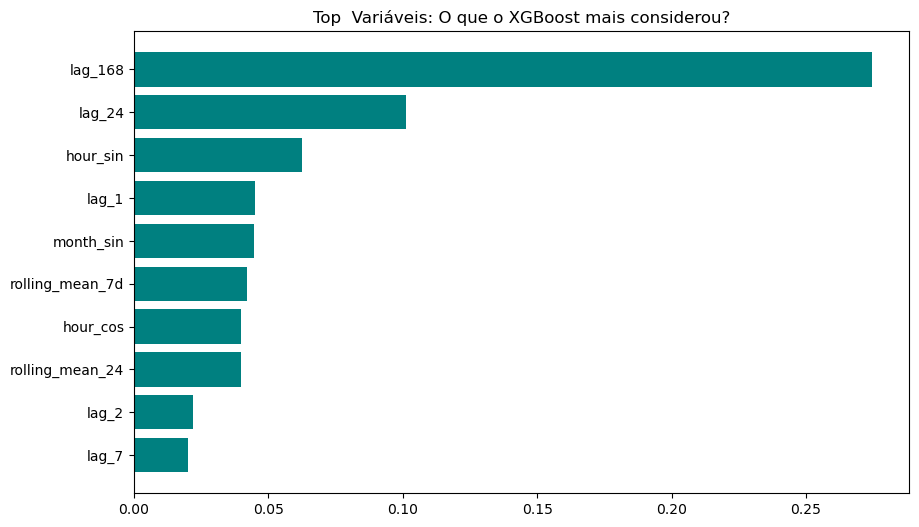

In [24]:
# Pegando as importâncias
modelo_escolhido = "XGBoost"

xgb_model = [r for r in resultados if r['nome'] == modelo_escolhido][0]['modelo']

importances = xgb_model.feature_importances_
feature_names = X_train.columns
 
# Criando o DataFrame para o gráfico
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(10)

# Plotando
plt.figure(figsize=(10, 6))
plt.barh(fi_df['feature'], fi_df['importance'], color='teal')
plt.gca().invert_yaxis()
plt.title('Top  Variáveis: O que o XGBoost mais considerou?')
plt.show()

# Conclusão

O projeto de previsão de demanda para a empresa Taxi Corrida Maluca foi concluído com sucesso, superando a meta estabelecida. O objetivo principal era desenvolver um modelo com erro REQM (RMSE) inferior a 48 no conjunto de teste.

Resultados de Desempenho:

- Modelo Recomendado: XGBoost

- Métrica Alcançada no conjunto de teste: 📉 RMSE no teste: 39.5554





Oportunidades de Melhoria:

Observou-se que o conjunto de teste (10% dos finais dos dados) situa-se em um período de tendência de alta na demanda. Visto que modelos baseados em árvores possuem limitações inerentes de extrapolação (não prevendo valores acima do máximo visto no treinamento), uma estratégia promissora seria a modelagem da diferenciação.Em vez de prever a demanda absoluta, o modelo passaria a prever o incremento (resíduo) em relação ao período anterior. 

Para a entrega final ao gestor, o sistema automatizaria a recomposição do valor: $Valor_{Anterior} + \Delta_{Predito} = Demanda_{Final}$. Essa técnica tende a mitigar o erro em cenários de crescimento contínuo e melhorar a precisão do REQM.

# Revisão da checklist

- [x]  O Jupyter Notebook está aberto.

- [x]  O código está livre de erros
- [x]  As células com o código foram organizadas em ordem de execução.
- [x]  Os dados foram baixados e preparados

- [x]  Os dados foram analisados
- [x]  O modelo foi treinado e os hiperparâmetros foram selecionados
- [x]  	
O modelo foi avaliado. Uma conclusão foi fornecida

- [x] 
O REQM para o conjunto de teste não é maior que 48